# Test Model

This acts as the first version of our model, where we will be splitting the data, creating a class to train/validate the data, and finally test a few different configurations of our model.


## Setting Up the Data

Before we begin splitting up the data, we first need to load in our nhanes_model_ready file and see what kind of data we are working with

In [40]:
#Libraries for Code
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pickle
import os
import pandas as pd

In [41]:
#Importing the Data

(Full_Data) = pd.read_csv("../data/processed/nhanes_model_ready_revise.csv")
print(Full_Data.shape)
split = input("What % split do you want for training/testing data?:")
split_idx = int(split)
split_idx = split_idx/100.0
print(split_idx)

(5265, 137)
0.7


So our data appears to focus on 5,625 patients with 137 different categories ranging from race, country of birth, number of children (ages 0-5 and 6-17), and for the case of our study, household income, income:poverty ratio, and tooth records.  While the income to poverty ratio is numerical, unfortunately our household income records are categorical, with each category depicting a different 'level' of household income:

![Household Income Key](/Users/jeffpinarchick/Desktop/DSAN_5300_Final_Project/images/Income_Records_Guide5300.png)

So, looking at the data, it seems like we could take this in 3 separate ways: First, use a multi-class categorical model to predict the 'income' level of patients with tooth records, a binary classification model to determine if someone is 'above' or 'below' the income:poverty ratio (where above 1 = not in poverty and below 1 = in poverty), and finally a linear model to determine the income:poverty ratio of a patient based on their tooth records.

### Measuring Tooth Records

In order to determine the 'tooth health' of an individual, we used the data's DMFT score, which is a scoring system that represents the sum of decayed(D), missing(M), and filled-in(F) teeth that a subject has.  For example, if Patient Jeff has 2 teeth filled in, and 1 tooth decayed from cavities, then he would have a score of 3.  Thus, if we were to make an early prediction, it would be that as the DMFT score approaches 0, the income:poverty rate/household income class should increase (having negative correlation with each other).

In [42]:
#Splitting The Data
task = (f'{input("Choose A Task That You Want to Use (multiclass, binary, or regression)")}')
X_raw = Full_Data[['dmft_score']].values
print(task)
print(X_raw)
if task == 'multiclass':
    valid_codes = sorted([c for c in Full_Data['household_income'].dropna().unique() if c not in [77,99]])
    code_map = {v: i for i,v in enumerate(valid_codes)}
    mask = Full_Data['household_income'].isin(valid_codes)
    X_raw = Full_Data.loc[mask, ['dmft_score']].values
    Y_raw = Full_Data.loc[mask, 'household_income'].map(code_map).values
    n_classes = len(valid_codes)
elif task == 'binary':
    Y_raw = (Full_Data['income_poverty_ratio'] > 1).astype(int).values
    n_classes = 2
elif task == 'regression':
    Y_raw = Full_Data['income_poverty_ratio'].values
    n_classes = 1

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
X_train, X_temp, Y_train, Y_temp = train_test_split(X_scaled, Y_raw, train_size=split_idx, random_state=42)
X_valid, X_Test, Y_valid, Y_Test = train_test_split(X_temp, Y_temp, test_size=0.50, random_state=42)
print(f"Task: {task} | Training Data Length: {len(X_train)} | Validation Data Length: {len(X_valid)} | Testing Data Length: {len(X_Test)}")
if task == 'multiclass':
    print(f"Number of classes: {n_classes}")

regression
[[14]
 [ 0]
 [28]
 ...
 [ 0]
 [ 1]
 [10]]
Task: regression | Training Data Length: 3685 | Validation Data Length: 790 | Testing Data Length: 790


In [46]:
#Making the Class
class DentalClassifier:
    def __init__(self, params):
        self.verbose = True
        default_params = {'l1_reg': 0.0, 'l2_reg': 0.0, 'dropout_rate': 0.0, 'hu1': 128, 'hu2': 64, 'hu3': 32,
                          'learning_rate': 0.001, 'epochs': 100, 'batch_size': 32, 'patience': 10, 'activation': 'relu', 'optimizer': 'adam',
                          'task': task, 'n_classes': n_classes, 'n_features': X_train.shape[1]}
        for key, val in default_params.items():
            setattr(self, key, val)
        for key, val in params.items():
            setattr(self, key, val)
        self.build_model()
        self.history = None

    def build_model(self):
        model = keras.Sequential()
        model.add(layers.Dense(self.hu1, input_shape=(self.n_features,), activation = self.activation, kernel_regularizer = keras.regularizers.L1L2(l1=self.l1_reg, l2=self.l2_reg)))
        model.add(layers.Dropout(self.dropout_rate))
        model.add(layers.Dense(self.hu2, activation = self.activation, kernel_regularizer = keras.regularizers.L1L2(l1=self.l1_reg, l2=self.l2_reg)))
        model.add(layers.Dropout(self.dropout_rate))
        model.add(layers.Dense(self.hu3, activation = self.activation, kernel_regularizer = keras.regularizers.L1L2(l1=self.l1_reg, l2=self.l2_reg)))
        model.add(layers.Dropout(self.dropout_rate))
        if self.task == 'multiclass':
            model.add(layers.Dense(self.n_classes, activation='softmax'))
            loss = 'sparse_categorical_crossentropy'
            metrics=['accuracy']
        elif self.task == 'binary':
            model.add(layers.Dense(1, activation = 'sigmoid'))
            loss = 'binary_crossentropy'
            metrics = ['accuracy']
        elif self.task == 'regression':
            model.add(layers.Dense(1, activation = 'linear'))
            loss='mse'
            metrics = ['mae']
        if self.optimizer == 'adam':
            opt = keras.optimizers.Adam(learning_rate = self.learning_rate)
        elif self.optimizer == 'sgd':
            opt = keras.optimizers.SGD(learning_rate = self.learning_rate)
        elif self.optimizer == 'rmsprop':
            opt = keras.optimizers.RMSprop(learning_rate=self.learning_rate)
        else:
            opt = self.optimizer
        model.compile(optimizer = opt, loss = loss, metrics = metrics)
        self.model = model
        print("Model Architecture:")
        model.summary()
    
    def train(self):
        stop_target = input("What Would You Like To Track? (accuracy, loss, val_accuracy, val_loss, mae, or val_mae):")
        mode_map = {'accuracy': 'max', 'val_accuracy': 'max', 'loss': 'min', 'val_loss': 'min', 'mae': 'min', 'val_mae': 'min'}
        mode = mode_map.get(stop_target, 'auto')
        early_stopping = keras.callbacks.EarlyStopping(monitor=stop_target, patience=self.patience, restore_best_weights=True, mode=mode, verbose=1)
        self.history = self.model.fit(X_train, Y_train, batch_size=self.batch_size, epochs = self.epochs, validation_data = (X_valid, Y_valid), callbacks = [early_stopping], verbose=1)
        return self.history
    
    def report(self, save_model=True, model_name = "Testing Model"):
        if self.history is None:
            print("Train the Model First.")
            return
        fig, axes = plt.subplots(2,3, figsize=(18,12))
        axes[0, 0].plot(self.history.history['loss'], label='Training Loss')
        axes[0, 0].plot(self.history.history['val_loss'], label='Validation Loss')
        axes[0, 0].set_title('Model Loss')
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].legend()
        axes[0, 0].grid(True)

        if self.task in ('multiclass', 'binary'):
            axes[0, 1].plot(self.history.history['accuracy'], label='Training Accuracy')
            axes[0, 1].plot(self.history.history['val_accuracy'], label='Validation Accuracy')
            axes[0, 1].set_title('Model Accuracy')
            axes[0, 1].set_xlabel('Epoch')
            axes[0, 1].set_ylabel('Accuracy')
            axes[0, 1].legend()
            axes[0, 1].grid(True)

            if self.task == 'multiclass':
                Y_train_pred = np.argmax(self.model.predict(X_train, verbose = 0), axis=1)
                Y_val_pred   = np.argmax(self.model.predict(X_valid, verbose=0), axis=1)
                Y_test_pred  = np.argmax(self.model.predict(X_Test,  verbose=0), axis=1)
            else:
                Y_train_pred = (self.model.predict(X_train, verbose=0) > 0.5).astype(int).flatten()
                Y_val_pred   = (self.model.predict(X_valid, verbose=0) > 0.5).astype(int).flatten()
                Y_test_pred  = (self.model.predict(X_Test,  verbose=0) > 0.5).astype(int).flatten()

            cm_train = confusion_matrix(Y_train, Y_train_pred)
            cm_val = confusion_matrix(Y_valid, Y_val_pred)
            cm_test = confusion_matrix(Y_Test, Y_test_pred)

            sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0])
            axes[1, 0].set_title('Training Set Confusion Matrix')
            axes[1, 0].set_xlabel('Predicted')
            axes[1, 0].set_ylabel('Actual')

            sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', ax=axes[1, 1])
            axes[1, 1].set_title('Validation Set Confusion Matrix')
            axes[1, 1].set_xlabel('Predicted')
            axes[1, 1].set_ylabel('Actual')

            sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=axes[1, 2])
            axes[1, 2].set_title('Test Set Confusion Matrix')
            axes[1, 2].set_xlabel('Predicted')
            axes[1, 2].set_ylabel('Actual')

            axes[0, 2].remove()

            plt.tight_layout()
            plt.show()

            print(classification_report(Y_train, Y_train_pred))
            print(classification_report(Y_valid, Y_val_pred))
            print(classification_report(Y_Test, Y_test_pred))
            train_acc = np.mean(Y_train == Y_train_pred)
            val_acc = np.mean(Y_valid == Y_val_pred)
            test_acc = np.mean(Y_Test == Y_test_pred)
            print(f"Training Accuracy:   {train_acc:.4f}")
            print(f"Validation Accuracy: {val_acc:.4f}")
            print(f"Test Accuracy:       {test_acc:.4f}")
            return {'train_acc': train_acc, 'val_acc': val_acc, 'test_acc': test_acc}
        
        elif self.task == 'regression':
            Y_train_pred = self.model.predict(X_train, verbose=0).flatten()
            Y_val_pred   = self.model.predict(X_valid, verbose=0).flatten()
            Y_test_pred  = self.model.predict(X_Test,  verbose=0).flatten()
            for ax, Y_true, Y_pred, title in zip([axes[1, 0], axes[1, 1], axes[1, 2]], [Y_train,    Y_valid,    Y_Test], [Y_train_pred, Y_val_pred, Y_test_pred], ['Training', 'Validation', 'Test']):
                ax.scatter(Y_true, Y_pred, alpha=0.3, s=10, color='steelblue')
                min_val = min(Y_true.min(), Y_pred.min())
                max_val = max(Y_true.max(), Y_pred.max())
                ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect Fit')
                ax.set_title(f'{title} Set: Actual vs Predicted')
                ax.set_xlabel('Actual Income:Poverty Ratio')
                ax.set_ylabel('Predicted Income:Poverty Ratio')
                ax.legend()
                ax.grid(True)
            axes[0, 1].clear()
            axes[0, 1].plot(self.history.history['mae'], label='Training MAE')
            axes[0, 1].plot(self.history.history['val_mae'], label='Validation MAE')
            axes[0, 1].set_title('Model MAE')
            axes[0, 1].set_xlabel('Epoch')
            axes[0, 1].set_ylabel('MAE')
            axes[0, 1].legend()
            axes[0, 1].grid(True)
            axes[0, 2].remove()
            plt.tight_layout()
            plt.show()

            train_mae  = mean_absolute_error(Y_train, Y_train_pred)
            val_mae    = mean_absolute_error(Y_valid, Y_val_pred)
            test_mae   = mean_absolute_error(Y_Test,  Y_test_pred)
            train_rmse = np.sqrt(mean_squared_error(Y_train, Y_train_pred))
            val_rmse   = np.sqrt(mean_squared_error(Y_valid, Y_val_pred))
            test_rmse  = np.sqrt(mean_squared_error(Y_Test,  Y_test_pred))

            print(f"Training   — MAE: {train_mae:.4f} | RMSE: {train_rmse:.4f}")
            print(f"Validation — MAE: {val_mae:.4f} | RMSE: {val_rmse:.4f}")
            print(f"Test       — MAE: {test_mae:.4f} | RMSE: {test_rmse:.4f}")

            return {'train_mae': train_mae, 'val_mae': val_mae, 'test_mae': test_mae,
                    'train_rmse': train_rmse, 'val_rmse': val_rmse, 'test_rmse': test_rmse}

        



            

Model Architecture:


/Users/jeffpinarchick/opt/anaconda3/envs/py311/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 14)             │           462 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,054 (43.18 KB)

 Trainable params: 11,054 (43.18 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1649 - loss: 2.5621 - val_accuracy: 0.2000 - val_loss: 2.5039
Epoch 2/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1945 - loss: 2.4917 - val_accuracy: 0.2000 - val_loss: 2.4629
Epoch 3/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1915 - loss: 2.4683 - val_accuracy: 0.1958 - val_loss: 2.4599
Epoch 4/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1936 - loss: 2.4664 - val_accuracy: 0.2000 - val_loss: 2.4472
Epoch 5/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1933 - loss: 2.4590 - val_accuracy: 0.2042 - val_loss: 2.4432
Epoch 6/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1939 - loss: 2.4601 - val_accuracy: 0.2042 - val_loss: 2.4425
Epoch 7/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1939 - loss: 2.4604 - val_accuracy: 0.2000 - val_loss: 2.4441
Epoch 8/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1948 - loss: 2.4546 - val_accuracy: 0.

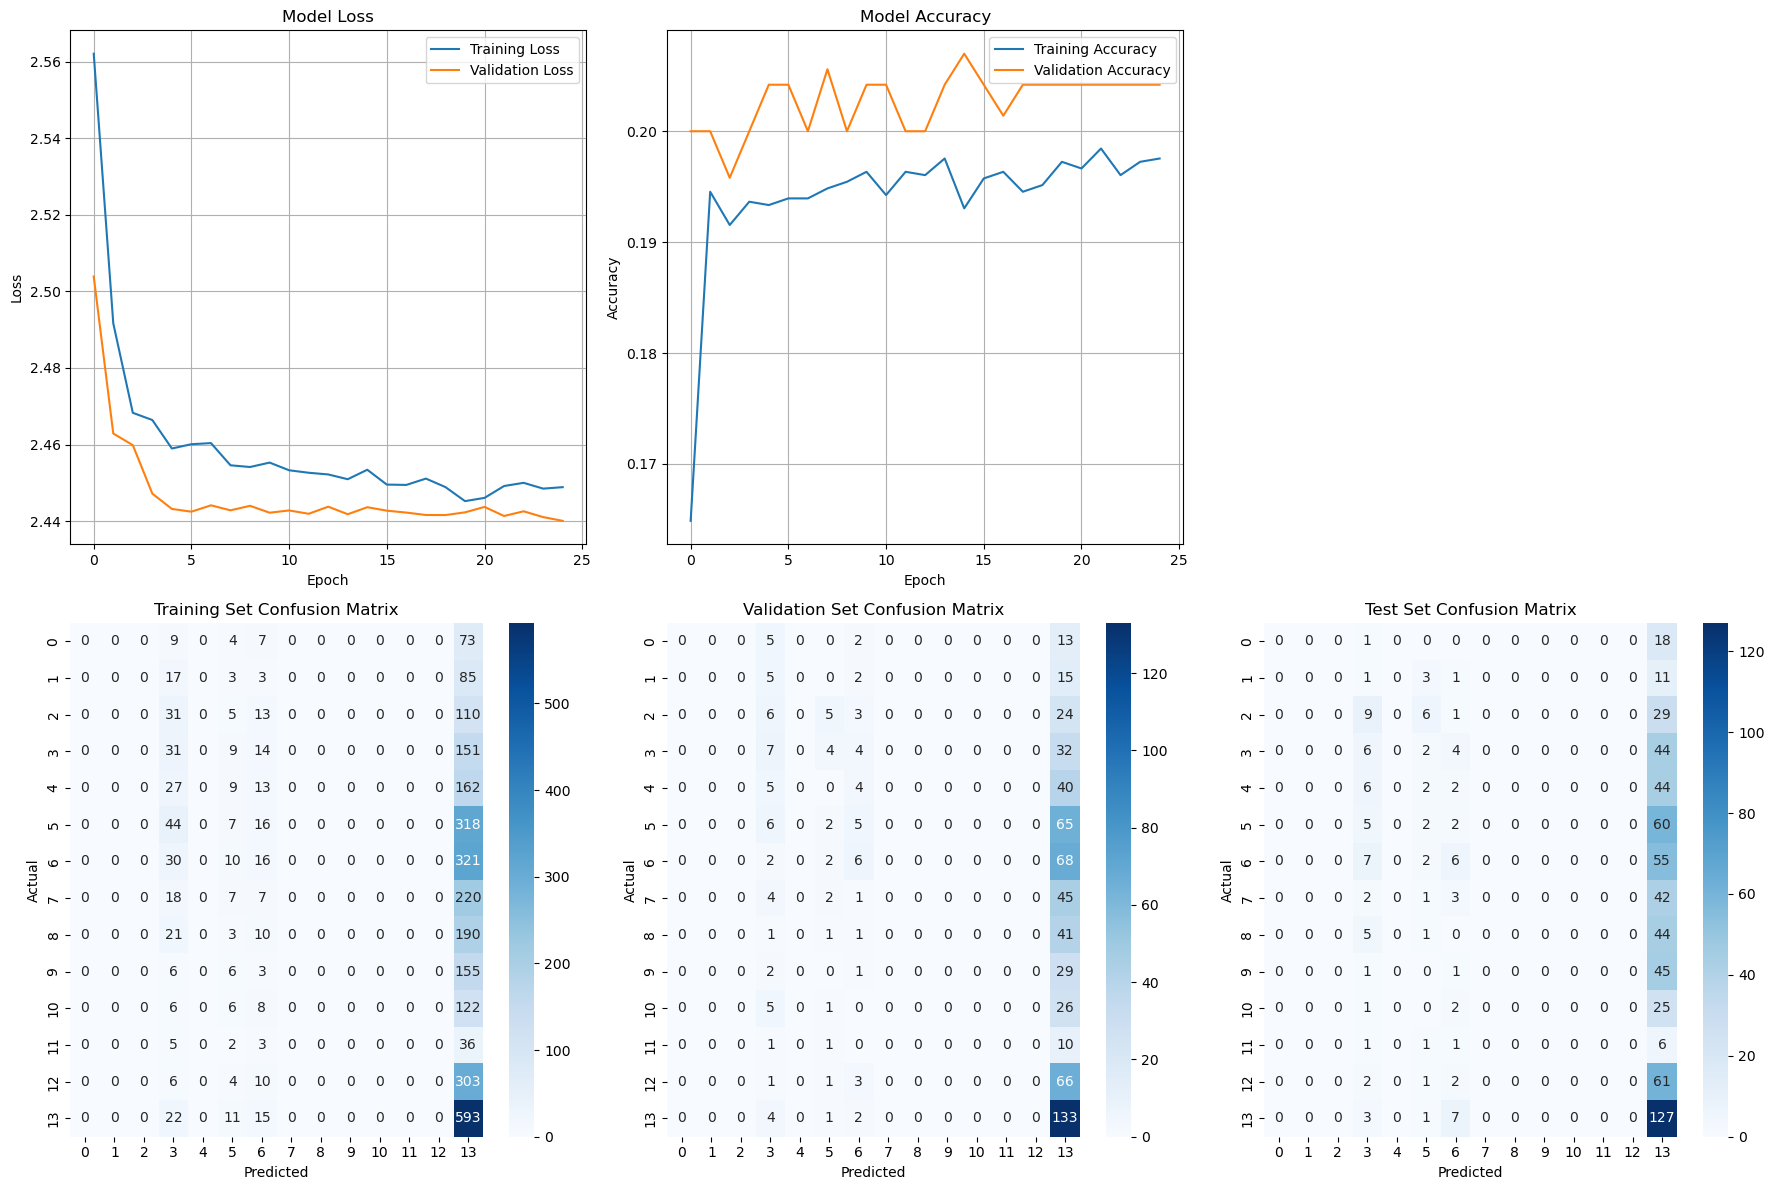

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        93
           1       0.00      0.00      0.00       108
           2       0.00      0.00      0.00       159
           3       0.11      0.15      0.13       205
           4       0.00      0.00      0.00       211
           5       0.08      0.02      0.03       385
           6       0.12      0.04      0.06       377
           7       0.00      0.00      0.00       252
           8       0.00      0.00      0.00       224
           9       0.00      0.00      0.00       170
          10       0.00      0.00      0.00       142
          11       0.00      0.00      0.00        46
          12       0.00      0.00      0.00       323
          13       0.21      0.93      0.34       641

    accuracy                           0.19      3336
   macro avg       0.04      0.08      0.04      3336
weighted avg       0.07      0.19      0.08      3336

              precision  

/Users/jeffpinarchick/opt/anaconda3/envs/py311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/jeffpinarchick/opt/anaconda3/envs/py311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/jeffpinarchick/opt/anaconda3/envs/py311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

In [ ]:
#First Test (multiclass, val_accuracy)
config1 = {'l1_reg': 0.0, 'l2_reg': 0.0, 'dropout_rate': 0.2, 'hu1': 128, 'hu2': 64,
           'hu3': 32, 'activation': 'relu', 'optimizer': 'adam', 'learning_rate': 0.001,
           'epochs': 50, 'batch_size': 32, 'patience': 10,
           'task': task, 'n_classes': n_classes, 'n_features': X_train.shape[1]}
model1 = DentalClassifier(config1)
model1.train()
results1 = model1.report(model_name="model1_baseline")
print(results1)

Model Architecture:


/Users/jeffpinarchick/opt/anaconda3/envs/py311/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,625 (41.50 KB)

 Trainable params: 10,625 (41.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8320 - loss: 0.4993 - val_accuracy: 0.8291 - val_loss: 0.4678
Epoch 2/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8320 - loss: 0.4619 - val_accuracy: 0.8291 - val_loss: 0.4639
Epoch 3/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8320 - loss: 0.4614 - val_accuracy: 0.8291 - val_loss: 0.4599
Epoch 4/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8320 - loss: 0.4651 - val_accuracy: 0.8291 - val_loss: 0.4600
Epoch 5/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8320 - loss: 0.4574 - val_accuracy: 0.8291 - val_loss: 0.4597
Epoch 6/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8320 - loss: 0.4590 - val_accuracy: 0.8291 - val_loss: 0.4589
Epoch 7/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8320 - loss: 0.4562 - val_accuracy: 0.8291 - val_loss: 0.4579
Epoch 8/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8320 - loss: 0.4562 - val_accuracy: 0.

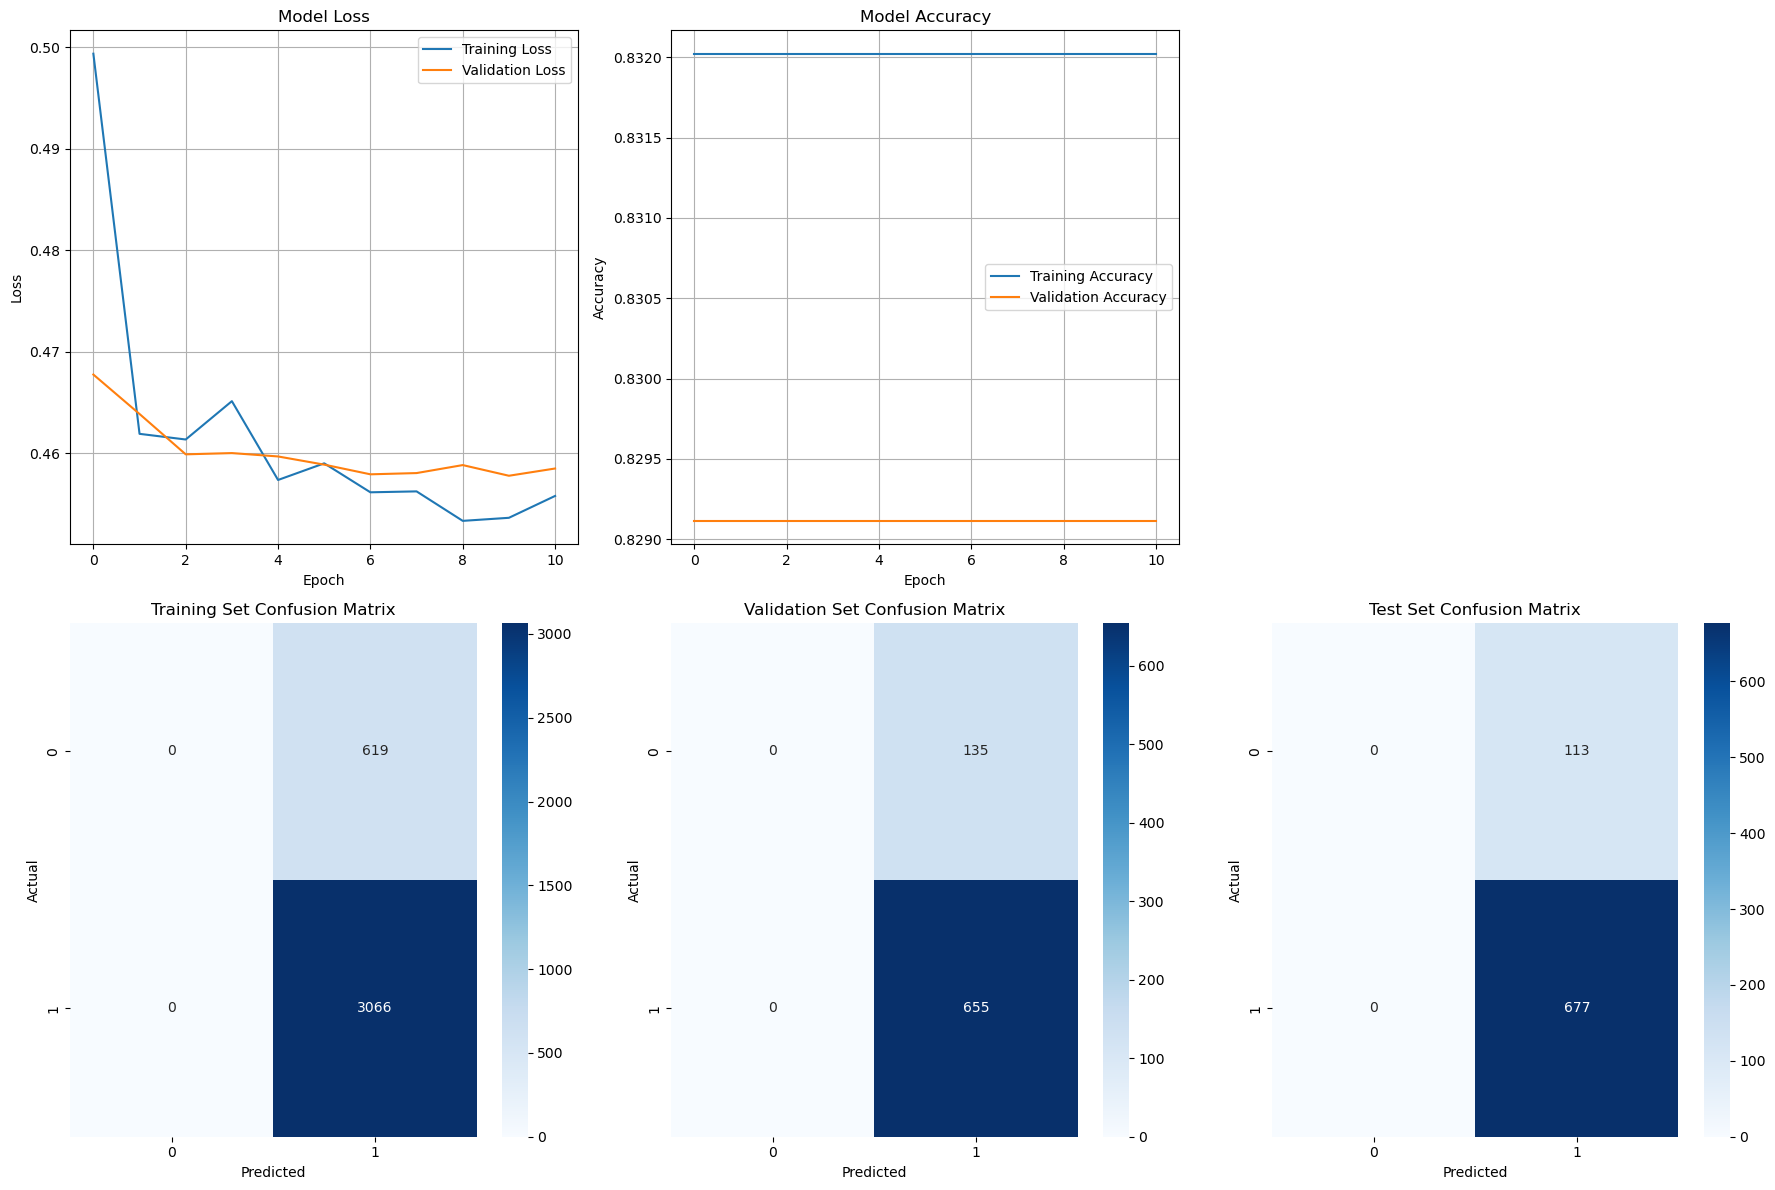

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       619
           1       0.83      1.00      0.91      3066

    accuracy                           0.83      3685
   macro avg       0.42      0.50      0.45      3685
weighted avg       0.69      0.83      0.76      3685

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       135
           1       0.83      1.00      0.91       655

    accuracy                           0.83       790
   macro avg       0.41      0.50      0.45       790
weighted avg       0.69      0.83      0.75       790

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       113
           1       0.86      1.00      0.92       677

    accuracy                           0.86       790
   macro avg       0.43      0.50      0.46       790
weighted avg       0.73      0.86      0.79       790

Training Accuracy: 

/Users/jeffpinarchick/opt/anaconda3/envs/py311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/jeffpinarchick/opt/anaconda3/envs/py311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/jeffpinarchick/opt/anaconda3/envs/py311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

In [ ]:
#Second Test: Binary (val_accuracy)
config2 = {'l1_reg': 0.0, 'l2_reg': 0.0, 'dropout_rate': 0.2, 'hu1': 128, 'hu2': 64,
           'hu3': 32, 'activation': 'relu', 'optimizer': 'adam', 'learning_rate': 0.001,
           'epochs': 50, 'batch_size': 32, 'patience': 10,
           'task': task, 'n_classes': n_classes, 'n_features': X_train.shape[1]}
model2 = DentalClassifier(config2)
model2.train()
results2 = model2.report(model_name="model2_baseline")
print(results2)

Model Architecture:


/Users/jeffpinarchick/opt/anaconda3/envs/py311/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,625 (41.50 KB)

 Trainable params: 10,625 (41.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 3.8691 - mae: 1.5632 - val_loss: 2.3169 - val_mae: 1.2420
Epoch 2/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.4596 - mae: 1.2906 - val_loss: 2.2628 - val_mae: 1.2486
Epoch 3/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.4391 - mae: 1.2891 - val_loss: 2.2641 - val_mae: 1.2660
Epoch 4/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.4046 - mae: 1.2820 - val_loss: 2.2752 - val_mae: 1.2456
Epoch 5/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.3994 - mae: 1.2782 - val_loss: 2.2763 - val_mae: 1.2407
Epoch 6/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.4011 - mae: 1.2847 - val_loss: 2.3318 - val_mae: 1.2149
Epoch 7/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.4080 - mae: 1.2831 - val_loss: 2.2960 - val_mae: 1.2304
Epoch 8/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.3708 - mae: 1.2681 - val_loss: 2.2644 - val_mae: 1.2666
Epoch 9/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - lo

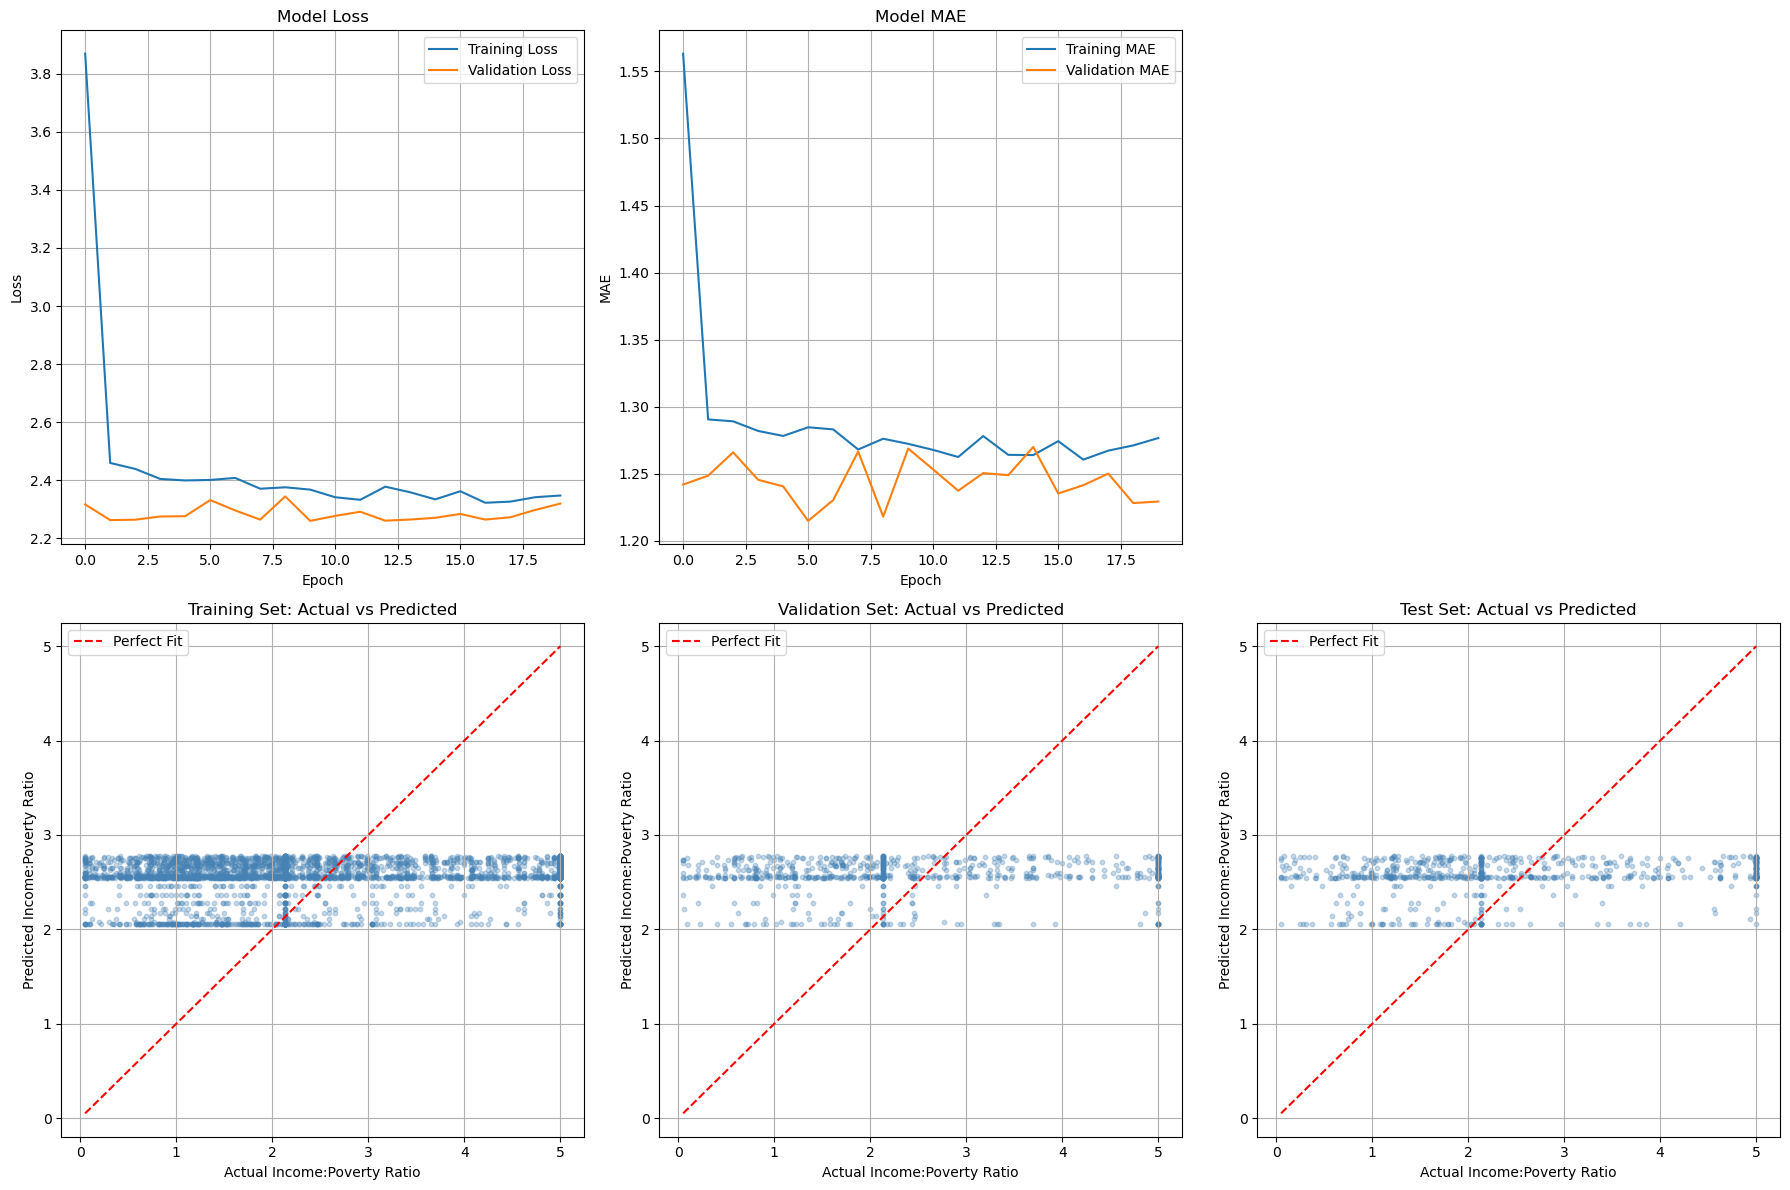

Training   — MAE: 1.2635 | RMSE: 1.4918
Validation — MAE: 1.2688 | RMSE: 1.5034
Test       — MAE: 1.2024 | RMSE: 1.4392
{'train_mae': 1.2634816952321068, 'val_mae': 1.2688282132088384, 'test_mae': 1.202389672617369, 'train_rmse': 1.4918226815323694, 'val_rmse': 1.503379772200437, 'test_rmse': 1.4391881220954161}


In [47]:
#Third Test (regression, val_mae)
config3 = {'l1_reg': 0.0, 'l2_reg': 0.0, 'dropout_rate': 0.2, 'hu1': 128, 'hu2': 64,
           'hu3': 32, 'activation': 'relu', 'optimizer': 'adam', 'learning_rate': 0.001,
           'epochs': 50, 'batch_size': 32, 'patience': 10,
           'task': task, 'n_classes': n_classes, 'n_features': X_train.shape[1]}
model3 = DentalClassifier(config3)
model3.train()
results3 = model3.report(model_name="model3_baseline")
print(results3)